### Install

In [1]:
%pip install "pandas<3.0.0" "google-genai" "python-dotenv" "openai" "scikit-learn" "seaborn" -U -q

Note: you may need to restart the kernel to use updated packages.


### Load API Keys

In [ ]:
from dotenv import load_dotenv
import os

# loading variables from .env
load_dotenv() 

#### Gemini

In [ ]:
from google import genai

client_gemini = genai.Client(
    api_key=os.getenv('GEMINI_API_KEY')
)

#### OpenAI

In [ ]:
from openai import OpenAI

# Looks for an environment variable named OPENAI_API_KEY
client_openai = OpenAI()

#### Anthropic

In [ ]:
import anthropic

client_claude = anthropic.Anthropic(
    api_key=os.getenv("ANTHROPIC_API_KEY")
)

### Speaker Profile Generation

In [2]:
import random
import time
from tqdm.auto import tqdm

def generate_global_bios(df):
    """Creates a dictionary of character summaries to give Gemini personality context."""
    bios = {}
    # We take a few sample lines for each speaker to 'prime' the model
    for speaker in df['Speaker'].unique():
        speaker_data = df[df['Speaker'] == speaker]['Utterance']
        
        sample_size = min(len(speaker_data), 10) 
        
        samples = speaker_data.sample(sample_size).tolist()
        samples_str = " ".join([f'"{s}"' for s in samples])
        bios[speaker] = f"{speaker} typically speaks like this: {samples_str}"
    return bios

/home/liaojd/SenticCrystal/meld_env/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


DIALOGUE BASED CONTEXT WINDOW

In [6]:
def predict_dialogue_emotions(bios, dialogue_group):
    """Sends an entire dialogue to Gemini 2.5 and gets a list of emotions back."""
    # Ensure labels are alphabetical as per your preference
    valid_labels = ["Anger", "Disgust", "Fear", "Joy", "Neutral", "Sadness", "Surprise"]
    
    # Format the dialogue turns for the prompt
    turns = [f"Turn {i+1} - {r['Speaker']}: {r['Utterance']}" for i, r in enumerate(dialogue_group)]
    dialogue_text = "\n".join(turns)
    
    # Filter bios to only those present in this specific dialogue
    relevant_bios = "\n".join([bios.get(s, "") for s in set(r['Speaker'] for r in dialogue_group)])

    prompt = f"""Task: Assign exactly one emotion label to EACH turn in the dialogue below.
    Return a JSON object with the key "predictions" containing a list of strings.
    The length of the list must be exactly {len(dialogue_group)}.

    SPEAKER CONTEXT:
    {relevant_bios}

    DIALOGUE TO ANALYZE:
    {dialogue_text}

    ALLOWED LABELS (Alphabetical): {valid_labels}

    Output Format: {{"predictions": ["Label1", "Label2", ...]}}"""

    # Using Gemini 2.5 Flash for speed and long-context reasoning
    # response = client.models.generate_content(
    #     model="gemini-2.5-flash",
    #     contents=prompt,
    #     config={'response_mime_type': 'application/json'}
    # )
    # # response = client.chat.completions.create(
    #     model="gpt-5.2", # Use gpt-4o if you want to save credits
    #     messages=[
    #         {"role": "user", "content": prompt}
    #     ],
    #     response_format={"type": "json_object"}
    # )
    
    # Parse the JSON response
    try:
        import json
        # predictions = json.loads(response.text)
        # # Basic validation: ensure it's a list and matches length
        # if not isinstance(predictions, list) or len(predictions) != len(dialogue_group):
        #     return ["Neutral"] * len(dialogue_group)
        # return [p if p in valid_labels else "Neutral" for p in predictions]
        response = client.models.generate_content(
        model="gemini-2.5-flash",
        contents=prompt,
        config={'response_mime_type': 'application/json'}
        )
        raw_content = response.text
        data = json.loads(raw_content)
        
        if isinstance(data, dict) and "predictions" in data:
            predictions = data["predictions"]
        elif isinstance(data, dict) and "emotions" in data: 
            predictions = data["emotions"]
        else:
            predictions = data

        if not isinstance(predictions, list) or len(predictions) != len(dialogue_group):
            return ["Neutral"] * len(dialogue_group)
            
        return [p if p in valid_labels else "Neutral" for p in predictions]
        
        # #chat gpt
        # raw_content = response.choices[0].message.content
        
        # # If GPT-5.2 returns {"emotions": [...]}, you'll need to grab the key.
        # # If it returns a raw list string "[...]", json.loads handles it.
        # data = json.loads(raw_content)
        
        # if isinstance(data, dict) and "predictions" in data:
        #     predictions = data["predictions"]
        # elif isinstance(data, dict) and "emotions" in data: # Backup check
        #     predictions = data["emotions"]
        # else:
        #     predictions = data

        # if not isinstance(predictions, list) or len(predictions) != len(dialogue_group):
        #     return ["Neutral"] * len(dialogue_group)
            
    #     # return [p if p in valid_labels else "Neutral" for p in predictions]
    except Exception as e:
        print(f"Parsing error: {e}")
        return ["Neutral"] * len(dialogue_group)

In [3]:
# CLAUDE
import os
def predict_dialogue_emotions2(bios, dialogue_group):
    import json
    import re # Added for cleaning the response
    valid_labels = ["Anger", "Disgust", "Fear", "Joy", "Neutral", "Sadness", "Surprise"]
    
    turns = [f"Turn {i+1} - {r['Speaker']}: {r['Utterance']}" for i, r in enumerate(dialogue_group)]
    dialogue_text = "\n".join(turns)
    relevant_bios = "\n".join([bios.get(s, "") for s in set(r['Speaker'] for r in dialogue_group)])

    system_prompt = f"""You are an expert emotion classifier. 
Assign exactly one emotion label to EACH turn in the dialogue.
ALLOWED LABELS (Alphabetical): {valid_labels}

Output Format: You MUST return a JSON object with the key "predictions" containing a list of strings."""

    user_prompt = f"""SPEAKER CONTEXT:
{relevant_bios}

DIALOGUE TO ANALYZE:
{dialogue_text}

The length of the 'predictions' list must be exactly {len(dialogue_group)}."""

    try:
        # Using the current 2026 stable model ID
        response = client_claude.messages.create(
            model="claude-sonnet-4-6", 
            max_tokens=2048,
            system=system_prompt,
            messages=[
                {"role": "user", "content": user_prompt}
            ]
        )

        raw_content = response.content[0].text
        
        # --- CLEANING LOGIC ---
        # 1. Strip whitespace
        raw_content = raw_content.strip()
        
        # 2. Use Regex to find the JSON block if Claude wrapped it in ```json
        # This prevents the "char 0" parsing error
        json_match = re.search(r'\{.*\}', raw_content, re.DOTALL)
        if json_match:
            raw_content = json_match.group(0)
        
        data = json.loads(raw_content)
        
        # Handle different potential key names
        predictions = data.get("predictions", data.get("emotions", data))

        if not isinstance(predictions, list) or len(predictions) != len(dialogue_group):
            return ["Neutral"] * len(dialogue_group)
            
        return [p if p in valid_labels else "Neutral" for p in predictions]

    except Exception as e:
        print(f"Claude API/Parsing error: {e}")
        # If it's a JSON error, printing the first 100 chars of raw_content helps debug
        return ["Neutral"] * len(dialogue_group)

processing data

In [4]:
import pandas as pd
def process_meld_batch(file_path, output_csv="hierarchical_results.csv"):
    df = pd.read_csv(file_path)
    df = df.sort_values(['Dialogue_ID', 'Utterance_ID'])

    processed_ids = set()
    if os.path.exists(output_csv):
        existing_df = pd.read_csv(output_csv)
        if not existing_df.empty:
            processed_ids = set(existing_df['Dialogue_ID'].unique())
            print(f"Skipping {len(processed_ids)} already processed dialogues.")
    
    bios = generate_global_bios(df)
    results = []
    grouped = df.groupby('Dialogue_ID')

    for diag_id, group in tqdm(grouped, desc="Processing Dialogues"):
        if diag_id in processed_ids:
            continue
        group_list = group.to_dict('records')
        try:
            predictions = predict_dialogue_emotions2(bios, group_list)
            
            curr_batch = []
            for i, row in enumerate(group_list):
                curr_batch.append({
                    'Dialogue_ID': diag_id,
                    'Utterance_ID': row['Utterance_ID'],
                    'Speaker': row['Speaker'],
                    'Original_Emotion': row['Emotion'],
                    'Predicted_Emotion': predictions[i] if i < len(predictions) else "Neutral"
                })
            
            new_df = pd.DataFrame(curr_batch)
            if not os.path.isfile(output_csv):
                new_df.to_csv(output_csv, index=False)
            else:
                new_df.to_csv(output_csv, mode='a', header=False, index=False)
            results.extend(curr_batch)
        except Exception as e:
            if "429" in str(e):
                print("\nQuota hit! Saving and exiting...")
                pd.DataFrame(results).to_csv(output_csv, index=False)
                return  # Exit gracefully so you can restart later
            print(f"Error at {diag_id}: {e}")

    return pd.DataFrame(results)

# Run it!
final_df = process_meld_batch(r"/home/liaojd/SenticCrystal/data/meld_7way_data/train_sent_emo.csv", "results_claude1.csv")

Processing Dialogues:  82%|████████▏ | 851/1038 [32:30<06:52,  2.20s/it] 

Claude API/Parsing error: Extra data: line 2 column 1 (char 217)


Processing Dialogues: 100%|██████████| 1038/1038 [39:01<00:00,  2.26s/it]


--- Classification Report ---
              precision    recall  f1-score   support

       anger       0.56      0.56      0.56      1109
     disgust       0.30      0.34      0.32       271
        fear       0.26      0.58      0.36       268
         joy       0.52      0.68      0.59      1743
     neutral       0.80      0.66      0.72      4710
     sadness       0.51      0.43      0.47       683
    surprise       0.58      0.61      0.60      1205

    accuracy                           0.62      9989
   macro avg       0.51      0.55      0.52      9989
weighted avg       0.65      0.62      0.63      9989

Overall Weighted F1 Score: 0.6282


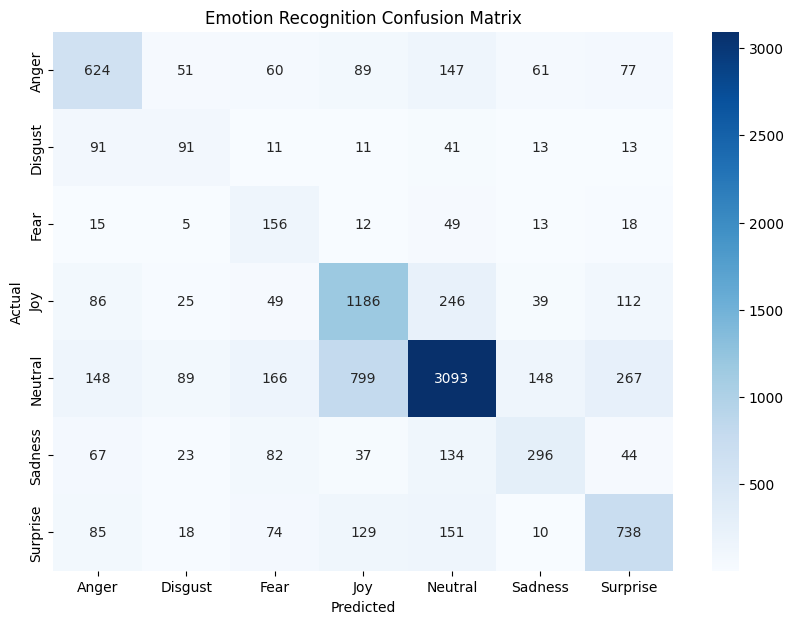

In [6]:
import pandas as pd
from sklearn.metrics import classification_report, confusion_matrix, f1_score
import seaborn as sns
import matplotlib.pyplot as plt

def evaluate_results(csv_file):
    df = pd.read_csv(csv_file)
    df['Predicted_Emotion'] = df['Predicted_Emotion'].astype(str).str.strip().str.lower()
    df['Original_Emotion'] = df['Original_Emotion'].astype(str).str.strip().str.lower()
    labels = ["anger", "disgust", "fear", "joy", "neutral", "sadness", "surprise"]

    print("--- Classification Report ---")
    # Adding zero_division=0 hides the warnings for missing labels
    print(classification_report(df['Original_Emotion'], 
                                df['Predicted_Emotion'], 
                                labels=labels,
                                zero_division=0))

    weighted_f1 = f1_score(df['Original_Emotion'], 
                           df['Predicted_Emotion'], 
                           average='weighted')
    print(f"Overall Weighted F1 Score: {weighted_f1:.4f}")
    cm = confusion_matrix(df['Original_Emotion'], 
                          df['Predicted_Emotion'], 
                          labels=labels)
    
    plt.figure(figsize=(10, 7))
    display_labels = [l.capitalize() for l in labels]
    sns.heatmap(cm, annot=True, fmt='d', xticklabels=display_labels, yticklabels=display_labels, cmap='Blues')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title('Emotion Recognition Confusion Matrix')
    plt.show()
evaluate_results("results_claude1.csv")

In [6]:
import pandas as pd

# Load your results
file_name = "results_gemini2.csv"
df = pd.read_csv(file_name)

print(f"--- Initial Stats ---")
print(f"Total rows: {len(df)}")

# 1. Identify and Drop Duplicates
# We use Dialogue_ID and Utterance_ID because that pair is the unique 'primary key' for MELD
df_cleaned = df.drop_duplicates(subset=['Dialogue_ID', 'Utterance_ID'], keep='first')

print(f"\n--- Cleaning Results ---")
print(f"Rows removed: {len(df) - len(df_cleaned)}")
print(f"Final unique rows: {len(df_cleaned)}")

# 2. Safety Check: Verify the Support number
# If your goal was the Train set, this should be exactly 9989
if len(df_cleaned) == 9989:
    print("✅ SUCCESS: Your support count matches the MELD Training set.")
elif len(df_cleaned) < 9989:
    print(f"⚠️ WARNING: You are missing {9989 - len(df_cleaned)} utterances. Did the script finish?")
else:
    print(f"❓ NOTE: You still have {len(df_cleaned)} rows. You might have merged Train + Dev.")

# 3. Save the clean file
output_name = "results_gemini2_final.csv"
df_cleaned.to_csv(output_name, index=False)
print(f"\nCleaned file saved as: {output_name}")

--- Initial Stats ---
Total rows: 16506

--- Cleaning Results ---
Rows removed: 6517
Final unique rows: 9989
✅ SUCCESS: Your support count matches the MELD Training set.

Cleaned file saved as: results_gemini2_final.csv


STOP HERE?


In [ ]:
def predict_dialogue_emotions_sliding(bios, dialogue_group, window_size=3):
    """
    Predicts emotions turn-by-turn using a sliding window.
    window_size=0: No previous context (just the current line)
    window_size=3: Current line + 3 previous lines
    """
    import json
    predictions = []
    valid_labels = ["Anger", "Disgust", "Fear", "Joy", "Neutral", "Sadness", "Surprise"]

    for i in range(len(dialogue_group)):
        # 1. Define the window: from (current - window_size) up to current
        start_idx = max(0, i - window_size)
        context_turns = dialogue_group[start_idx : i + 1] # Includes the current turn
        
        # 2. Format the turns for the prompt
        # We label them clearly so the AI knows which one is the "Target"
        formatted_context = []
        for j, r in enumerate(context_turns):
            prefix = "CONTEXT" if j < (len(context_turns) - 1) else "TARGET (Predict this)"
            formatted_context.append(f"{prefix} - {r['Speaker']}: {r['Utterance']}")
        
        context_text = "\n".join(formatted_context)
        
        # 3. Get bios for speakers in this specific window
        current_speakers = set(r['Speaker'] for r in context_turns)
        relevant_bios = "\n".join([bios.get(s, "") for s in current_speakers])

        prompt = f"""Task: Assign exactly one emotion label to the TARGET turn.
Use the provided CONTEXT turns to understand the emotional flow.

SPEAKER CONTEXT:
{relevant_bios}

DIALOGUE WINDOW:
{context_text}

ALLOWED LABELS: {valid_labels}
Return ONLY a JSON string containing the label, e.g., "Neutral"."""

        # 4. API Call per turn
        try:
            response = client.models.generate_content(
                model="gemini-2.5-flash",
                contents=prompt,
                config={'response_mime_type': 'application/json'}
            )
            label = json.loads(response.text)
            predictions.append(label if label in valid_labels else "Neutral")
        except:
            predictions.append("Neutral")

    return predictions

In [ ]:
def predict_dialogue_emotions_window(bios, dialogue_group):
    """Sends an entire dialogue to Gemini 2.5 and gets a list of emotions back."""
    # Ensure labels are alphabetical as per your preference
    valid_labels = ["Anger", "Disgust", "Fear", "Joy", "Neutral", "Sadness", "Surprise"]
    
    # Format the dialogue turns for the prompt
    turns = [f"Turn {i+1} - {r['Speaker']}: {r['Utterance']}" for i, r in enumerate(dialogue_group)]
    dialogue_text = "\n".join(turns)
    
    # Filter bios to only those present in this specific dialogue
    relevant_bios = "\n".join([bios.get(s, "") for s in set(r['Speaker'] for r in dialogue_group)])
    window_size = 3
    prompt = f"""Task: Assign exactly one emotion label to EACH turn in the dialogue below.
Return a JSON list of strings of length {len(dialogue_group)}.

CRITICAL RULE for Window Size {window_size}:
When deciding the emotion for "Turn N", you must ONLY consider the text in "Turn N" and the 
{window_size} turns immediately preceding it. 
DO NOT use information from any turns that come AFTER "Turn N". 

SPEAKER CONTEXT:
{relevant_bios}

DIALOGUE TO ANALYZE:
{dialogue_text}

ALLOWED LABELS: {valid_labels}
Output Format: ["Label1", "Label2", ...]"""
    # Using Gemini 2.5 Flash for speed and long-context reasoning
    response = client.models.generate_content(
        model="gemini-2.5-flash",
        contents=prompt,
        config={'response_mime_type': 'application/json'}
    )
    
    # Parse the JSON response
    try:
        import json
        predictions = json.loads(response.text)
        # Basic validation: ensure it's a list and matches length
        if not isinstance(predictions, list) or len(predictions) != len(dialogue_group):
            return ["Neutral"] * len(dialogue_group)
        return [p if p in valid_labels else "Neutral" for p in predictions]
    except:
        return ["Neutral"] * len(dialogue_group)